# Load Libs

In [1]:
import importlib

%load_ext autoreload
%autoreload 2
import dwMRI_analysis_functions as dwMRI_AF



# Dipy
import dipy as dp
from dipy.io.image import load_nifti, save_nifti
from dipy.io import read_bvals_bvecs
from dipy.core.gradients import gradient_table
import dipy.data as dpd
from dipy.tracking import utils

#Preproc
from dipy.align import motion_correction
import dipy.direction.peaks as dpp
#from dipy.viz import window, actor
from dipy.segment.mask import median_otsu
from dipy.core.histeq import histeq


#DIPY Plot
from dipy.viz import window, actor, colormap
from dipy.data import get_sphere, default_sphere, get_fnames

#Regular Packages
import keyboard  # For detecting keypresses
import IPython
import pickle #loading pkl files (dictonairy)
import pandas as pd

from pathlib import Path


import numpy as np
import os
from pathlib import Path
from time import time
import time  # For simulating work
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib import colormaps
import scipy.io

#Plot packages
import napari

#Model Packages
from dipy.direction import peaks_from_model
from dipy.reconst.dti import color_fa
from dipy.reconst.csdeconv import auto_response_ssst
from dipy.reconst.dti import TensorModel
from dipy.reconst.shm import CsaOdfModel
import dipy.reconst.sfm as sfm
import dipy.reconst.dki as dki
import dipy.reconst.dti as dti
from dipy.tracking.stopping_criterion import (ActStoppingCriterion,
                                              BinaryStoppingCriterion,
                                              ThresholdStoppingCriterion)

segment_info = {
    "C1":  {"pct": 1.6, "cum_pct": 1.6},
    "C2":  {"pct": 2.2, "cum_pct": 3.9},
    "C3":  {"pct": 3.5, "cum_pct": 7.3},
    "C4":  {"pct": 3.5, "cum_pct": 10.8},
    "C5":  {"pct": 3.5, "cum_pct": 14.3},
    "C6":  {"pct": 3.3, "cum_pct": 17.6},
    "C7":  {"pct": 3.2, "cum_pct": 20.8},
    "C8":  {"pct": 3.4, "cum_pct": 24.1},
    "T1":  {"pct": 3.6, "cum_pct": 27.7},
    "T2":  {"pct": 3.9, "cum_pct": 31.6},
    "T3":  {"pct": 4.4, "cum_pct": 36.0},
    "T4":  {"pct": 5.0, "cum_pct": 41.0},
    "T5":  {"pct": 5.1, "cum_pct": 46.1},
    "T6":  {"pct": 5.6, "cum_pct": 51.8},
    "T7":  {"pct": 5.6, "cum_pct": 57.4},
    "T8":  {"pct": 5.4, "cum_pct": 62.7},
    "T9":  {"pct": 5.1, "cum_pct": 67.8},
    "T10": {"pct": 4.7, "cum_pct": 72.4},
    "T11": {"pct": 4.3, "cum_pct": 76.7},
    "T12": {"pct": 3.9, "cum_pct": 80.6},
    "L1":  {"pct": 3.6, "cum_pct": 84.2},
    "L2":  {"pct": 2.8, "cum_pct": 87.0},
    "L3":  {"pct": 2.4, "cum_pct": 89.4},
    "L4":  {"pct": 2.2, "cum_pct": 91.6},
    "L5":  {"pct": 1.7, "cum_pct": 93.3},
    "S1":  {"pct": 1.5, "cum_pct": 94.9},
    "S2":  {"pct": 1.6, "cum_pct": 96.4},
    "S3":  {"pct": 1.4, "cum_pct": 97.8},
    "S4":  {"pct": 1.3, "cum_pct": 99.1},
    "S5":  {"pct": 0.9, "cum_pct": 100.0},
}
segment_cum_pct = {
    "C1": 1.6, "C2": 3.9, "C3": 7.3, "C4": 10.8, "C5": 14.3, "C6": 17.6, "C7": 20.8, "C8": 24.1,
    "T1": 27.7, "T2": 31.6, "T3": 36.0, "T4": 41.0, "T5": 46.1, "T6": 51.8, "T7": 57.4, "T8": 62.7,
    "T9": 67.8, "T10": 72.4, "T11": 76.7, "T12": 80.6,
    "L1": 84.2, "L2": 87.0, "L3": 89.4, "L4": 91.6, "L5": 93.3,
    "S1": 94.9, "S2": 96.4, "S3": 97.8, "S4": 99.1, "S5": 100.0,
}

min_z = 10
max_z = -150
t2, affine_t2 = load_nifti("Data/Rotated and Transposed/RARE_combined_trans_denoised_gibbs_masked_rotated_BFC_corrected20.nii.gz")
t2 = t2[:,:,min_z:max_z]

# Calculate actual z-index for all spinal segments using cum_pct and t2 z-dimension
z_dim = t2.shape[2]
segment_z_index = {}

for seg, info in segment_info.items():
    cum_pct = info["cum_pct"]
    z_idx = int(round((cum_pct / 100) * (z_dim - 1)))
    segment_z_index[seg] = z_idx

print(segment_z_index)


def slice_mean_sem(vol, mask): 
    """vol: (X,Y,Z) metric; mask: (X,Y,Z) bool"""
    # zero-out non-GM; mark them NaN for nan-reductions
    arr_masked = np.where(mask, vol, np.nan)
    mean_z = np.nanmean(arr_masked, axis=(0,1))


    n      = np.sum(np.isfinite(arr_masked), axis=(0,1))
    mean_z = np.nanmean(arr_masked,          axis=(0,1))
    var_z  = np.nanvar(arr_masked,           axis=(0,1), ddof=1)  # sample variance
    sem_z  = np.sqrt(var_z) / np.sqrt(n)
    sem_z  = np.where(n > 1, sem_z, np.nan)  # guard small n

    return mean_z, sem_z

/home/cfp406/cfp406/miniconda3/envs/DIPY/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'C1': 29, 'C2': 70, 'C3': 132, 'C4': 195, 'C5': 258, 'C6': 318, 'C7': 375, 'C8': 435, 'T1': 500, 'T2': 570, 'T3': 649, 'T4': 740, 'T5': 832, 'T6': 934, 'T7': 1035, 'T8': 1131, 'T9': 1223, 'T10': 1306, 'T11': 1384, 'T12': 1454, 'L1': 1519, 'L2': 1569, 'L3': 1613, 'L4': 1652, 'L5': 1683, 'S1': 1712, 'S2': 1739, 'S3': 1764, 'S4': 1788, 'S5': 1804}


# MRI Ansisotropy + ODI Analysis

In [2]:
df_no_background = pd.read_csv("Data/voxelwise_data.csv")

In [19]:
"""
Spinal Cord Anisotropy Analysis Pipeline
==========================================
Full workflow for quantifying and statistically comparing tissue anisotropy
across spinal segments and tissue types (white matter / gray matter).

Steps
-----
1. Quantify anisotropy per ROI
       - Fractional Anisotropy (FA) from structure tensor
       - Coherence Index (CI) — ratio of sorted eigenvalues
       - Orientation Index (OI) — circular variance of local orientations
2. Test spatial autocorrelation (Moran's I) within each section
3. Fit Linear Mixed Model (LMM) with tissue_type × segment interaction
       + spatial covariance (distance-decay random effect)
4. Post-hoc comparisons (Tukey HSD + FDR-corrected pairwise tests)
5. Visualise results

Replace the data generation block (Step 0) with your real image data.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy import stats
from scipy.spatial.distance import cdist
from skimage.feature import structure_tensor
from skimage.filters import gaussian
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import libpysal.weights as lw
from esda.moran import Moran
import tqdm

# ═════════════════════════════════════════════════════════════════════════════
# CONFIGURATION  — edit these to match your experiment
# ═════════════════════════════════════════════════════════════════════════════

#SEGMENTS     =  segment_z_index.keys() #["C1", "C5", "T1", "T5"]          # spinal levels
#TISSUE_TYPES = ["WM", "GM"]                       # white matter, gray matter
N_SUBJECTS   = 1                                  # animals / donors
N_ROIS       = 30                                 # ROIs per section (per subject × segment × tissue)


MORAN_THRESHOLD_QUANTILE = 0.25                   # distance threshold for Moran weight matrix
                                                   # (use 25th percentile of pairwise distances)
ALPHA        = 0.05                               # significance level
SEED         = 42



# ═════════════════════════════════════════════════════════════════════════════
# STEP 2 — SPATIAL AUTOCORRELATION (Moran's I)
# ═════════════════════════════════════════════════════════════════════════════

def run_morans_i(df: pd.DataFrame, variable: str = "FA", group_by = ["segment", "tissue_type"]) -> pd.DataFrame:
    """
    Test for spatial autocorrelation within each section
    (subject × segment × tissue_type combination).

    Uses a distance-band spatial weights matrix: two ROIs are neighbours
    if they fall within the MORAN_THRESHOLD_QUANTILE of all pairwise distances.

    Returns a summary DataFrame with Moran's I statistic and p-value per section.
    """
    print(f"\n  Running Moran's I on '{variable}' within each section...")
    results = []

    groups = df.groupby(group_by)
    with tqdm.tqdm(total=len(groups), desc="  Sections") as pbar:
        for group_keys, grp in groups:
            if len(grp) < 5:
                continue

            coords = grp[["x", "y"]].values
            vals   = grp[variable].values

            # Build distance-band weight matrix
            dists  = cdist(coords, coords)
            thresh = np.quantile(dists[dists > 0], MORAN_THRESHOLD_QUANTILE)
            try:
                w = lw.distance.DistanceBand.from_array(
                    coords, threshold=thresh, binary=True, silence_warnings=True
                )
                if w.n_components > 1:       # disconnected graph → row-standardise anyway
                    pass
                w.transform = "r"            # row-standardise
                mi = Moran(vals, w, permutations=499)
                results.append({
                    "Segment":     group_keys[0],
                    "Tissue": group_keys[1],
                    "n_rois":      len(grp),
                    "morans_I":    mi.I,
                    "expected_I":  mi.EI,
                    "p_value":     mi.p_sim,
                    "significant": mi.p_sim < ALPHA,
                })
            except Exception as e:
                results.append({
                    "Segment": group_keys[0], "Tissue": group_keys[1],
                    "n_rois": len(grp), "morans_I": np.nan,
                    "expected_I": np.nan, "p_value": np.nan,
                    "significant": False,
                })

        moran_df = pd.DataFrame(results)

        n_sig = moran_df["significant"].sum()
        n_tot = len(moran_df)
        print(f"  Spatial autocorrelation significant (p<{ALPHA}) in "
            f"{n_sig}/{n_tot} sections ({100*n_sig/n_tot:.0f}%)")

        # Print section-level summary
        summary = (moran_df.groupby(["Segment", "Tissue"])
                [["morans_I", "p_value", "significant"]]
                .mean()
                .round(3))
        print("\n  Mean Moran's I by segment × tissue type:")
        print(summary.to_string())

        return moran_df


# ═════════════════════════════════════════════════════════════════════════════
# STEP 3 — LINEAR MIXED MODEL
# ═════════════════════════════════════════════════════════════════════════════

def build_spatial_covariance_term(df: pd.DataFrame, group_by = ["Segment", "Tissue"]) -> pd.DataFrame:
    """
    Create a spatial covariance adjustment column.

    Strategy: for each section, regress the anisotropy variable on a
    smooth spatial trend (thin-plate spline basis via x, y, x², y², xy).
    The residuals are the spatially-detrended anisotropy values.
    The spatial trend itself is saved as 'spatial_trend' and added as
    a fixed covariate in the LMM to absorb within-section spatial structure.

    This is a practical alternative to a full GP random effect inside the LMM
    and is computationally much cheaper for larger datasets.
    """
    df = df.copy()
    df["spatial_trend"] = 0.0

    for _, grp in df.groupby(group_by):
        idx = grp.index
        x = grp["x"].values
        y = grp["y"].values

        # Quadratic spatial basis: [1, x, y, x², y², xy]
        X_sp = np.column_stack([x, y, x**2, y**2, x * y])
        fa   = grp["FA"].values

        try:
            coef, _, _, _ = np.linalg.lstsq(
                np.column_stack([np.ones(len(x)), X_sp]), fa, rcond=None
            )
            trend = np.column_stack([np.ones(len(x)), X_sp]) @ coef
        except Exception:
            trend = np.zeros(len(x))

        df.loc[idx, "spatial_trend"] = trend

    return df


def fit_lmm(df: pd.DataFrame, group_by = ["Segment", "Tissue"]) -> dict:
    """
    Fit a Linear Mixed Model:

        FA ~ tissue_type * segment + spatial_trend   (fixed effects)
                                  (random intercept)

    The tissue_type × segment interaction term tests whether anisotropy
    differences between tissue types change across spinal segments.
    spatial_trend absorbs within-section spatial autocorrelation.

    Returns dict with model result and ANOVA table.
    """
    print("\n  Fitting LMM: FA ~ tissue_type * segment + spatial_trend...")

    df = df.copy()
    df["FA_z"] = (df["FA"] - df["FA"].mean()) / df["FA"].std()  # standardise outcome
    formula = f"FA_z ~  {' * '.join(group_by)} + spatial_trend"
    print("  LMM formula:", formula)
    model   = smf.mixedlm(formula, df, groups= df["z"])
    result  = model.fit(reml=True, method="lbfgs")

    print("\n  ── LMM Fixed Effects ──────────────────────────────────────────")
    fe = result.summary().tables[1]
    print(fe.to_string())
    print(f"\n  Log-likelihood: {result.llf:.2f} | "
          f"AIC: {result.aic:.2f} | "
          f"BIC: {result.bic:.2f}")

    # Likelihood ratio test: model vs. intercept-only (test overall fixed effects)
    null_model  = smf.mixedlm("FA_z ~ 1", df, groups=df["z"])
    null_result = null_model.fit(reml=False, method="lbfgs")
    full_refit  = smf.mixedlm(formula, df, groups=df["z"]).fit(reml=False, method="lbfgs")
    LR_stat     = 2 * (full_refit.llf - null_result.llf)
    df_diff     = full_refit.df_modelwc - null_result.df_modelwc
    LR_p        = stats.chi2.sf(LR_stat, df=max(df_diff, 1))

    print(f"\n  Likelihood Ratio Test vs. null: χ²({int(df_diff)}) = {LR_stat:.2f}, "
          f"p = {LR_p:.4f}")

    return {"result": result, "LR_stat": LR_stat, "LR_p": LR_p, "df": df}


# ═════════════════════════════════════════════════════════════════════════════
# STEP 4 — POST-HOC COMPARISONS
# ═════════════════════════════════════════════════════════════════════════════

def posthoc_comparisons(df: pd.DataFrame, variable: str = "FA", group_by = ["Segment", "Tissue"]) -> dict:
    """
    Two complementary post-hoc comparison strategies:

    A) Tukey HSD across all tissue_type × segment combinations
       Controls familywise error rate (FWER); conservative.

    B) FDR-corrected pairwise t-tests (Benjamini–Hochberg)
       - Between tissue types within each segment
       - Between segments within each tissue type
       Less conservative than Tukey for many comparisons.

    Returns dict with both result tables.
    """
    print("\n  Running post-hoc comparisons...")

    df = df.copy()
    df["group"] = df[group_by[0]] + "_" + df[group_by[1]]

    # ── A: Tukey HSD ─────────────────────────────────────────────────────────
    tukey = pairwise_tukeyhsd(df[variable], df["group"], alpha=ALPHA)
    tukey_df = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0],
    )
    tukey_df.columns = ["group1", "group2", "meandiff", "p_adj",
                        "lower", "upper", "reject"]
    tukey_df["meandiff"] = tukey_df["meandiff"].astype(float).round(4)
    tukey_df["p_adj"]    = tukey_df["p_adj"].astype(float).round(4)

    n_sig_tukey = tukey_df["reject"].sum()
    print(f"\n  A) Tukey HSD: {n_sig_tukey}/{len(tukey_df)} pairs significant at α={ALPHA}")

    # ── B: FDR pairwise (tissue type within each segment) ────────────────────
    fdr_rows = []
    # i) Tissue type contrast within each segment
    for seg in SEGMENTS:
        sub = df[df["Segment"] == seg]
        wm  = sub[sub["Tissue"] == "WM"][variable]
        gm  = sub[sub["Tissue"] == "GM"][variable]
        if len(wm) > 1 and len(gm) > 1:
            t, p = stats.ttest_ind(wm, gm, equal_var=False)  # Welch t-test
            fdr_rows.append({
                "comparison_type": "tissue within segment",
                "group1": f"WM_{seg}",
                "group2": f"GM_{seg}",
                "mean1":  wm.mean(),
                "mean2":  gm.mean(),
                "diff":   wm.mean() - gm.mean(),
                "t_stat": t,
                "p_raw":  p,
            })

    # ii) Segment contrasts within each tissue type
    for ttype in TISSUE_TYPES:
        sub = df[df["Tissue"] == ttype]
        for i, seg1 in enumerate(SEGMENTS):
            for seg2 in SEGMENTS[i+1:]:
                g1 = sub[sub["Segment"] == seg1][variable]
                g2 = sub[sub["Segment"] == seg2][variable]
                if len(g1) > 1 and len(g2) > 1:
                    t, p = stats.ttest_ind(g1, g2, equal_var=False)
                    fdr_rows.append({
                        "comparison_type": "segment within tissue",
                        "group1": f"{ttype}_{seg1}",
                        "group2": f"{ttype}_{seg2}",
                        "mean1":  g1.mean(),
                        "mean2":  g2.mean(),
                        "diff":   g1.mean() - g2.mean(),
                        "t_stat": t,
                        "p_raw":  p,
                    })

    fdr_df = pd.DataFrame(fdr_rows)
    _, p_adj, _, _ = multipletests(fdr_df["p_raw"], alpha=ALPHA, method="fdr_bh")
    fdr_df["p_adj_fdr"] = p_adj.round(4)
    fdr_df["significant"] = p_adj < ALPHA
    fdr_df[["mean1","mean2","diff","t_stat","p_raw"]] = (
        fdr_df[["mean1","mean2","diff","t_stat","p_raw"]].round(4)
    )

    n_sig_fdr = fdr_df["significant"].sum()
    print(f"  B) FDR (BH): {n_sig_fdr}/{len(fdr_df)} pairs significant at q={ALPHA}")

    # Print significant FDR results
    sig = fdr_df[fdr_df["significant"]]
    if len(sig):
        print("\n  Significant FDR comparisons:")
        print(sig[["comparison_type","group1","group2","diff","t_stat","p_raw","p_adj_fdr"]]
              .to_string(index=False))

    return {"tukey": tukey_df, "fdr": fdr_df, "tukey_obj": tukey}


# ═════════════════════════════════════════════════════════════════════════════
# STEP 5 — VISUALISATION
# ═════════════════════════════════════════════════════════════════════════════

def plot_results(
    aniso_df:    pd.DataFrame,
    moran_df:    pd.DataFrame,
    posthoc:     dict,
    lmm_result:  dict,
    out_path = None, 
    group_by = ["Segment", "Tissue"],
) -> None:
    """
    Six-panel figure:
      A) FA distributions by tissue type (violin)
      B) FA by spinal segment (violin)
      C) Tissue × Segment interaction plot (means ± SE)
      D) Moran's I heatmap across sections
      E) Tukey HSD significant pairs
      F) FDR pairwise comparison heatmap
    """
    palette = {"WM": "#2E86AB", "GM": "#E84855"}
    seg_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(SEGMENTS)))

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        "Spinal Cord Anisotropy Analysis\n"
        "FA · Moran's I · LMM (Tissue × Segment) · Post-hoc",
        fontsize=13, fontweight="bold", y=0.99,
    )
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

    # ── A: FA by tissue type ──────────────────────────────────────────────
    ax_a = fig.add_subplot(gs[0, 0])
    for i, ttype in enumerate(TISSUE_TYPES):
        vals = aniso_df[aniso_df["Tissue"] == ttype]["FA"]
        parts = ax_a.violinplot(vals, positions=[i], widths=0.6,
                                showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(palette[ttype])
            pc.set_alpha(0.75)
        parts["cmedians"].set_color("white")
        parts["cmedians"].set_linewidth(2)
    ax_a.set_xticks([0, 1])
    ax_a.set_xticklabels(TISSUE_TYPES)
    ax_a.set_ylabel("Fractional Anisotropy (FA)")
    ax_a.set_title("A  FA by Tissue Type", fontweight="bold")
    ax_a.grid(axis="y", alpha=0.3)

    # ── B: FA by segment ─────────────────────────────────────────────────
    ax_b = fig.add_subplot(gs[0, 1])
    for i, seg in enumerate(SEGMENTS):
        vals = aniso_df[aniso_df["Segment"] == seg]["FA"]
        parts = ax_b.violinplot(vals, positions=[i], widths=0.6,
                                showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(seg_colors[i])
            pc.set_alpha(0.75)
        parts["cmedians"].set_color("white")
        parts["cmedians"].set_linewidth(2)
    ax_b.set_xticks(range(len(SEGMENTS)))
    ax_b.set_xticklabels(SEGMENTS)
    ax_b.set_ylabel("Fractional Anisotropy (FA)")
    ax_b.set_title("B  FA by Spinal Segment", fontweight="bold")
    ax_b.grid(axis="y", alpha=0.3)

    # ── C: Interaction plot ───────────────────────────────────────────────
    ax_c = fig.add_subplot(gs[0, 2])
    x_pos = np.arange(len(SEGMENTS))
    for ttype, col in palette.items():
        means, ses = [], []
        for seg in SEGMENTS:
            sub = aniso_df[(aniso_df["Tissue"] == ttype) &
                           (aniso_df["Segment"] == seg)]["FA"]
            means.append(sub.mean())
            ses.append(sub.sem())
        ax_c.errorbar(x_pos, means, yerr=ses, fmt="-o", color=col,
                      label=ttype, capsize=4, linewidth=2, markersize=6)
    ax_c.set_xticks(x_pos)
    ax_c.set_xticklabels(SEGMENTS)
    ax_c.set_ylabel("Mean FA ± SE")
    ax_c.set_title("C  Tissue × Segment Interaction", fontweight="bold")
    ax_c.legend(title="Tissue", fontsize=8)
    ax_c.grid(alpha=0.3)

    # ── D: Moran's I heatmap ──────────────────────────────────────────────
    ax_d = fig.add_subplot(gs[1, 0])
    pivot = moran_df.groupby(["Segment", "Tissue"])["morans_I"].mean().unstack()
    pivot = pivot.reindex(SEGMENTS)
    im = ax_d.imshow(pivot.values, cmap="RdYlGn", vmin=-0.3, vmax=0.6, aspect="auto")
    plt.colorbar(im, ax=ax_d, label="Moran's I")
    ax_d.set_xticks(range(len(TISSUE_TYPES)))
    ax_d.set_xticklabels(pivot.columns)
    ax_d.set_yticks(range(len(SEGMENTS)))
    ax_d.set_yticklabels(SEGMENTS)
    # Overlay significance markers
    piv_p = moran_df.groupby(["Segment", "Tissue"])["p_value"].mean().unstack()
    piv_p = piv_p.reindex(SEGMENTS)
    for r in range(len(SEGMENTS)):
        for c, col_name in enumerate(pivot.columns):
            p = piv_p.iloc[r, c] if col_name in piv_p.columns else 1.0
            marker = "**" if p < 0.01 else ("*" if p < ALPHA else "")
            ax_d.text(c, r, f"{pivot.iloc[r, c]:.2f}\n{marker}",
                      ha="center", va="center", fontsize=7.5,
                      color="black" if pivot.iloc[r, c] < 0.4 else "white")
    ax_d.set_title("D  Moran's I (mean per section)\n* p<0.05  ** p<0.01",
                   fontweight="bold")

    # ── E: Tukey HSD — sig pairs as dot plot ─────────────────────────────
    ax_e = fig.add_subplot(gs[1, 1:])
    tukey_df = posthoc["tukey"].copy()
    tukey_df["meandiff"] = tukey_df["meandiff"].astype(float)
    tukey_df["lower"]    = tukey_df["lower"].astype(float)
    tukey_df["upper"]    = tukey_df["upper"].astype(float)
    tukey_df["reject"]   = tukey_df["reject"].astype(bool)
    sig_t = tukey_df[tukey_df["reject"]].reset_index(drop=True)
    if len(sig_t):
        y_pos = range(len(sig_t))
        colors_e = ["#E84855" if d > 0 else "#2E86AB"
                    for d in sig_t["meandiff"].astype(float)]
        ax_e.barh(y_pos, sig_t["meandiff"].astype(float),
                  xerr=[sig_t["meandiff"].astype(float) - sig_t["lower"].astype(float),
                        sig_t["upper"].astype(float) - sig_t["meandiff"].astype(float)],
                  color=colors_e, alpha=0.8, capsize=3, height=0.6)
        ax_e.axvline(0, color="black", lw=1, ls="--")
        ax_e.set_yticks(y_pos)
        ax_e.set_yticklabels(
            [f"{r['group1']} vs {r['group2']}" for _, r in sig_t.iterrows()],
            fontsize=7
        )
        ax_e.set_xlabel("Mean difference in FA (Tukey HSD)")
    else:
        ax_e.text(0.5, 0.5, "No significant Tukey pairs", ha="center", va="center",
                  transform=ax_e.transAxes)
    ax_e.set_title("E  Tukey HSD — Significant Pairs", fontweight="bold")
    ax_e.grid(axis="x", alpha=0.3)

    # ── F: FDR heatmap ────────────────────────────────────────────────────
    ax_f = fig.add_subplot(gs[2, :])
    fdr_df  = posthoc["fdr"].copy()
    # Build a symmetric p-value matrix over all unique groups
    all_groups = sorted(set(fdr_df["group1"]) | set(fdr_df["group2"]))
    n_g = len(all_groups)
    p_matrix = np.ones((n_g, n_g))
    gidx = {g: i for i, g in enumerate(all_groups)}
    for _, row in fdr_df.iterrows():
        i, j = gidx[row["group1"]], gidx[row["group2"]]
        p_matrix[i, j] = row["p_adj_fdr"]
        p_matrix[j, i] = row["p_adj_fdr"]
    np.fill_diagonal(p_matrix, 1.0)

    im_f = ax_f.imshow(p_matrix, cmap="RdYlGn_r", vmin=0, vmax=0.1, aspect="auto")
    plt.colorbar(im_f, ax=ax_f, label="FDR-adjusted p-value", shrink=0.6)
    ax_f.set_xticks(range(n_g))
    ax_f.set_xticklabels(all_groups, rotation=45, ha="right", fontsize=7)
    ax_f.set_yticks(range(n_g))
    ax_f.set_yticklabels(all_groups, fontsize=7)
    for i in range(n_g):
        for j in range(n_g):
            if i != j:
                p = p_matrix[i, j]
                marker = "**" if p < 0.01 else ("*" if p < ALPHA else "")
                ax_f.text(j, i, marker, ha="center", va="center",
                          fontsize=8, color="white" if p < 0.05 else "grey")
    ax_f.set_title("F  FDR-Corrected Pairwise p-values (BH)\n* q<0.05  ** q<0.01",
                   fontweight="bold")

    if out_path is not None:    
        plt.savefig(out_path, dpi = 600, bbox_inches="tight")
        print(f"\n  Saved figure → {out_path}")
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# STEP 6 — SAVE SUMMARY TABLES
# ═════════════════════════════════════════════════════════════════════════════

def save_tables(
    aniso_df:   pd.DataFrame,
    moran_df:   pd.DataFrame,
    posthoc:    dict,
    group_by = ["Segment", "Tissue"],
    out_dir = None,
) -> None:
    """Save per-ROI anisotropy, Moran's I, and post-hoc results to CSV."""
    base = "~/" if out_dir is None else out_dir

    cols = ["z","Segment","Tissue","roi_id","x","y","FA","CI","OI","dominant_angle"]
    aniso_df[cols].to_csv(f"{base}/roi_anisotropy.csv", index=False)
    moran_df.to_csv(f"{base}/morans_i_results.csv", index=False)
    posthoc["tukey"].to_csv(f"{base}/posthoc_tukey.csv", index=False)
    posthoc["fdr"].to_csv(f"{base}/posthoc_fdr.csv", index=False)

    print(f"\n  Saved tables → roi_anisotropy.csv, morans_i_results.csv,")
    print(f"                  posthoc_tukey.csv, posthoc_fdr.csv")




## Run the analysis

In [4]:
df_no_background["Segment_Tissue"] = df_no_background["Segment"] + "_" + df_no_background["Tissue"]
df_no_background

,Unnamed: 0,x,y,z,ODI,FA,AD,RD,MD,NDI,Tissue,Segment,region,Segment_Tissue
0,1639863,9,44,923,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T6,thoracic,T6_WM
1,1639864,9,44,924,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T6,thoracic,T6_WM
2,1639874,9,44,934,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T6,thoracic,T6_WM
3,1639875,9,44,935,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T7,thoracic,T7_WM
4,1639878,9,44,938,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T7,thoracic,T7_WM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760863,10146174,58,53,269,0.390000,0.365382,3.500911e-04,1.891585e-04,2.428027e-04,0.99,WM,C6,cervical,C6_WM
1760864,10146175,58,53,270,0.404196,0.363642,3.251405e-04,1.763784e-04,2.259658e-04,0.99,WM,C6,cervical,C6_WM
1760865,10319170,59,52,1790,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,S5,sacral,S5_WM
1760866,10319171,59,52,1791,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,S5,sacral,S5_WM


In [ ]:
df_test= df_no_background.copy()
df_test["Segment"] = df_no_background["region"]

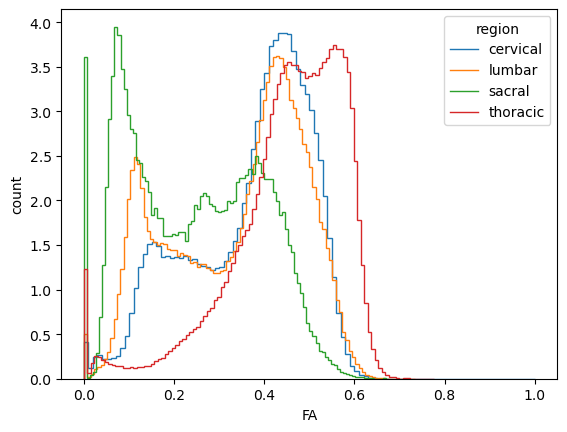

In [23]:
def plot_hist_large(df, col, hue="region", bins=100):
    fig, ax = plt.subplots()
    
    for region, group in df.groupby(hue):
        counts, edges = np.histogram(group[col].dropna(), bins=bins, density= True)
        ax.stairs(counts, edges, label=region)  # plots ~100 points, not 1.7B
    
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.legend(title=hue)
    plt.show()

plot_hist_large(df_no_background, "FA", hue="region", bins=100)

In [5]:
df_segment_tissue = df_no_background.drop_duplicates(subset="Segment_Tissue", keep="first")
df_subset = df_no_background[df_no_background["z"].isin(df_segment_tissue["z"])]
df_subset["Segment"] = df_subset["region"]

In [20]:
# ═════════════════════════════════════════════════════════════════════════════
# CONFIGURATION  — edit these to match your experiment
# ═════════════════════════════════════════════════════════════════════════════

SEGMENTS     =  df_subset["Segment"].unique() #["C1", "C5", "T1", "T5"]          # spinal levels
TISSUE_TYPES = ["WM", "GM"]                       # white matter, gray matter
N_SUBJECTS   = 1                                  # animals / donors
N_ROIS       = 30                                 # ROIs per section (per subject × segment × tissue)


MORAN_THRESHOLD_QUANTILE = 0.25                   # distance threshold for Moran weight matrix
                                                   # (use 25th percentile of pairwise distances)
ALPHA        = 0.05                               # significance level
SEED         = 42

In [9]:
# ── 2. Moran's I ──────────────────────────────────────────────────────
print("\n[3/5] Testing spatial autocorrelation (Moran's I)...")
moran_df = run_morans_i(df_subset , group_by= ["Segment", "Tissue"], variable="FA")


# ── 3. LMM ────────────────────────────────────────────────────────────
print("\n[4/5] Fitting Linear Mixed Model...")
aniso_df = build_spatial_covariance_term(df_subset, group_by=["Segment", "Tissue"])
lmm      = fit_lmm(aniso_df, group_by=["Segment", "Tissue"])

# ── 4. Post-hoc ───────────────────────────────────────────────────────
print("\n[5/5] Post-hoc comparisons...")
posthoc = posthoc_comparisons(aniso_df, variable="FA", group_by=["Segment", "Tissue"])



[3/5] Testing spatial autocorrelation (Moran's I)...

  Running Moran's I on 'FA' within each section...
  Spatial autocorrelation significant (p<0.05) in 8/8 sections (100%)

  Mean Moran's I by segment × tissue type:
                 morans_I  p_value  significant
Segment  Tissue                                
cervical GM         0.008    0.002          1.0
         WM         0.119    0.002          1.0
lumbar   GM         0.109    0.002          1.0
         WM         0.092    0.002          1.0
sacral   GM         0.232    0.002          1.0
         WM         0.060    0.002          1.0
thoracic GM         0.158    0.002          1.0
         WM         0.122    0.002          1.0

[4/5] Fitting Linear Mixed Model...

  Fitting LMM: FA ~ tissue_type * segment + spatial_trend...
  LMM formula: FA_z ~  Segment * Tissue + spatial_trend


/home/cfp406/cfp406/miniconda3/envs/DIPY/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/cfp406/cfp406/miniconda3/envs/DIPY/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/cfp406/cfp406/miniconda3/envs/DIPY/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/cfp406/cfp406/miniconda3/envs/DIPY/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)



  ── LMM Fixed Effects ──────────────────────────────────────────
                                   Coef.    Std.Err.        z  P>|z|        [0.025       0.975]
Intercept                         -0.393                                                       
Segment[T.lumbar]                 -0.018                                                       
Segment[T.sacral]                  0.003  991582.814    0.000  1.000  -1943466.600  1943466.606
Segment[T.thoracic]               -0.107                                                       
Tissue[T.WM]                      -0.032       0.015   -2.178  0.029        -0.061       -0.003
Segment[T.lumbar]:Tissue[T.WM]    -0.038       0.018   -2.073  0.038        -0.073       -0.002
Segment[T.sacral]:Tissue[T.WM]    -0.021       0.020   -1.099  0.272        -0.060        0.017
Segment[T.thoracic]:Tissue[T.WM]   0.010       0.019    0.554  0.579        -0.026        0.047
spatial_trend                      6.651       0.049  136.714  0.000 

In [21]:
# ── 5. Plots & tables ─────────────────────────────────────────────────
print("\nGenerating figures and saving output tables...")
plot_results(aniso_df, moran_df, posthoc, lmm, group_by=["Segment", "Tissue"], out_path = "Figures/dwMRI_anisotropy_analysis.svg")



Generating figures and saving output tables...

  Saved figure → Figures/dwMRI_anisotropy_analysis.svg


In [48]:

save_tables(aniso_df, moran_df, posthoc)

print("\n" + "=" * 65)
print(" Done.")
print("=" * 65)

print("""
Output files
────────────
anisotropy_analysis.png   — six-panel figure
roi_anisotropy.csv        — per-ROI FA, CI, OI, orientation angle
morans_i_results.csv      — per-section Moran's I and p-values
posthoc_tukey.csv         — Tukey HSD pairwise results
posthoc_fdr.csv           — FDR-corrected pairwise t-tests

To use with your own data
─────────────────────────
Replace generate_synthetic_data() with a function that returns a
DataFrame with these columns:
  subject        str   animal / donor ID
  segment        str   spinal level (e.g. "C3", "T1")
  tissue_type    str   "WM" or "GM" (or your own labels)
  roi_id         int   unique ROI identifier
  x, y           float 2-D coordinates within the tissue section
  image          ndarray  (ROI_SIZE_PX × ROI_SIZE_PX) float image patch

All downstream steps run automatically from there.
""")

KeyError: "['roi_id', 'CI', 'OI', 'dominant_angle'] not in index"